In [2]:
import pandas as pd
import numpy as np

# Библиотеки за визуелизација
import matplotlib.pyplot as plt
import seaborn as sns

# Библиотеки за претпроцесирање
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

# Библиотеки за модел и евалуација
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv('adult.csv', na_values='?')

In [4]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        46043 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       46033 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   47985 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [7]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [8]:
df.describe(include='object')

,workclass,education,marital-status,occupation,relationship,race,gender,native-country,income
count,46043,48842,48842,46033,48842,48842,48842,47985,48842
unique,8,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33906,15784,22379,6172,19716,41762,32650,43832,37155


In [9]:
df.isnull().sum()

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

In [10]:
df['income'].value_counts(normalize=True)

income
<=50K    0.760718
>50K     0.239282
Name: proportion, dtype: float64

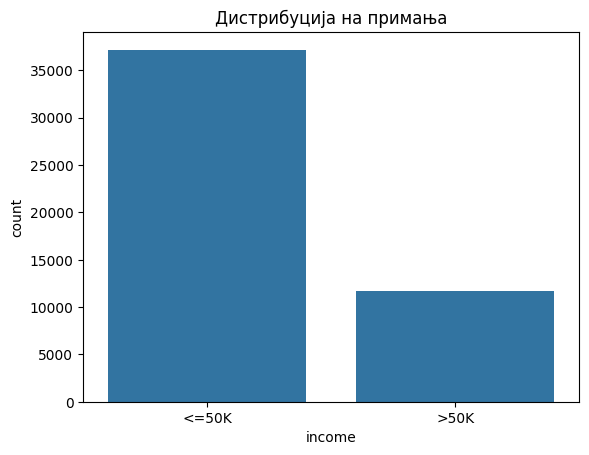

In [11]:
sns.countplot(x='income', data=df)
plt.title('Дистрибуција на примања')
plt.show()

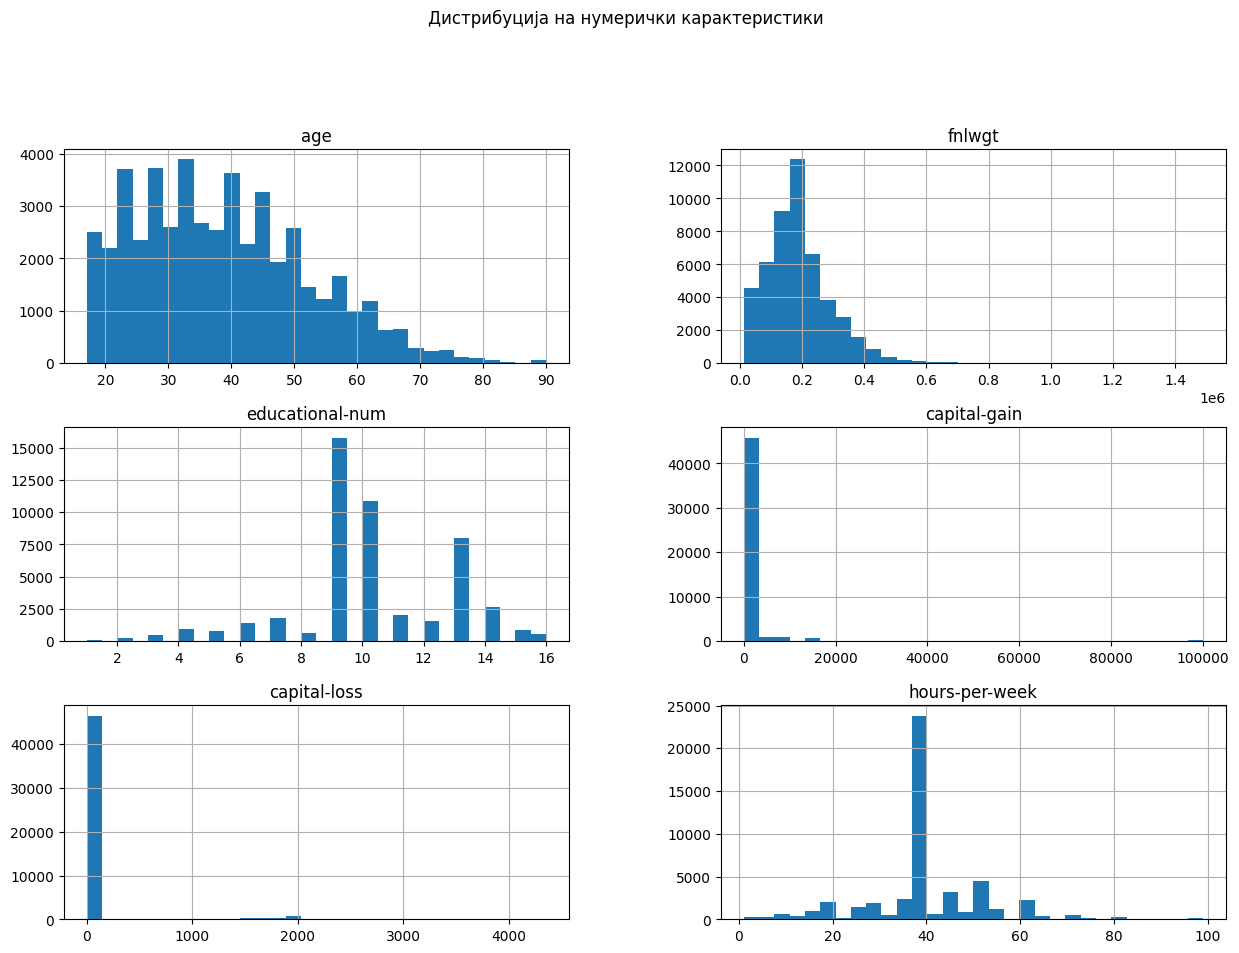

In [12]:
# Избор на нумерички колони
numeric_cols = df.select_dtypes(include=np.number).columns

# Креирање хистограми за нумеричките колони
df[numeric_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle('Дистрибуција на нумерички карактеристики', y=1.02)
plt.show()

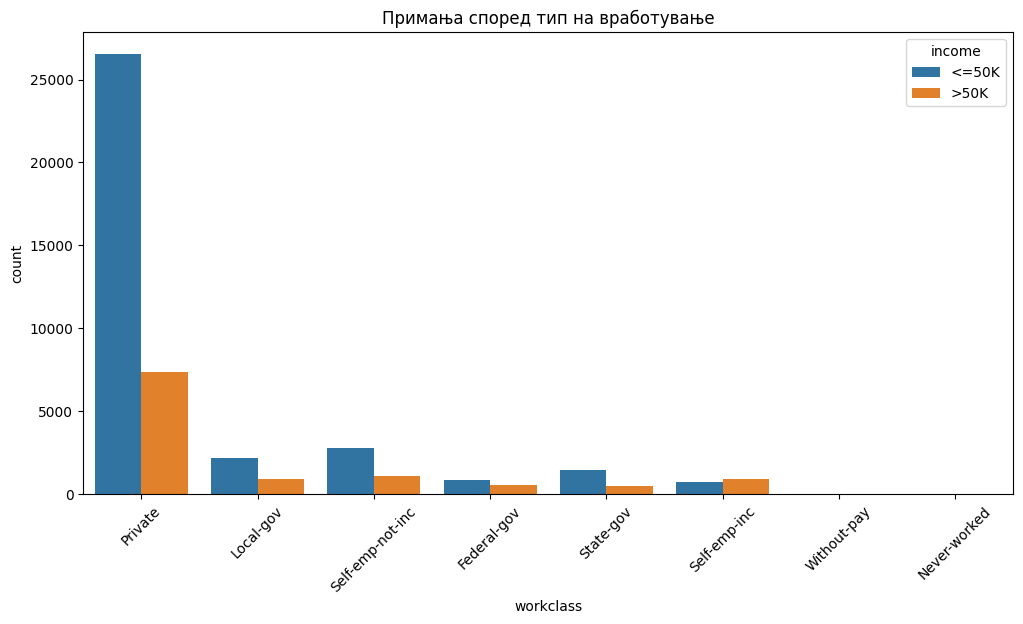

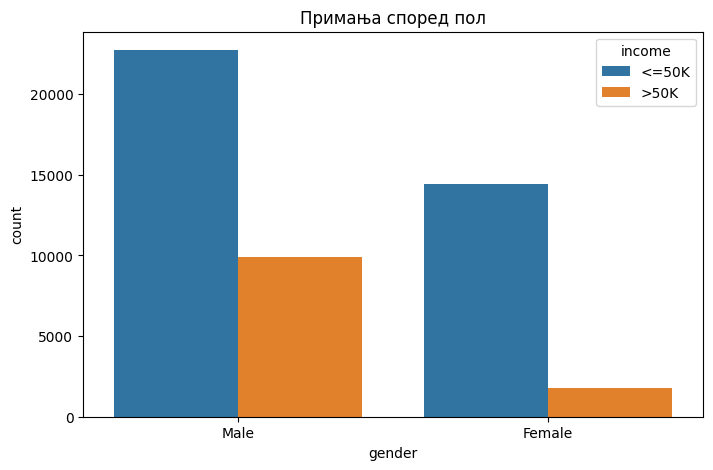

In [13]:
# Врска помеѓу 'workclass' и 'income'
plt.figure(figsize=(12, 6))
sns.countplot(x='workclass', hue='income', data=df)
plt.title('Примања според тип на вработување')
plt.xticks(rotation=45)
plt.show()

# Врска помеѓу 'gender' и 'income'
plt.figure(figsize=(8, 5))
sns.countplot(x='gender', hue='income', data=df)
plt.title('Примања според пол')
plt.show()

In [14]:
# Отстранување на колони што не ни се потребни
df_processed = df.drop(['fnlwgt', 'education'], axis=1)

# Дефинирање на карактеристики (X) и целна променлива (y)
X = df_processed.drop('income', axis=1)
y = df_processed['income']

print("Големина на X (карактеристики):", X.shape)
print("Големина на y (целна променлива):", y.shape)

Големина на X (карактеристики): (48842, 12)
Големина на y (целна променлива): (48842,)


In [15]:
# Иницијализација на LabelEncoder
le = LabelEncoder()

# Трансформација на 'y'
y_encoded = le.fit_transform(y)

# 'le.classes_' ни покажува кое енкодирање е применето
# 0 ќе биде '<=50K', 1 ќе биде '>50K'
print("Класи пред енкодирање:", le.classes_)
print("Пример од 'y' по енкодирање:", y_encoded[:5])

Класи пред енкодирање: ['<=50K' '>50K']
Пример од 'y' по енкодирање: [0 0 1 1 0]


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

print("Големина на сет за обука:", X_train.shape)
print("Големина на сет за тестирање:", X_test.shape)

Големина на сет за обука: (39073, 12)
Големина на сет за тестирање: (9769, 12)


In [17]:
# Идентификација на имињата на колоните според тип
numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include='object').columns

print("Нумерички карактеристики:", list(numeric_features))
print("Категориски карактеристики:", list(categorical_features))

Нумерички карактеристики: ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Категориски карактеристики: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']


In [18]:
# --- 1. Imputer за нумерички колони ---
num_imputer = SimpleImputer(strategy='median')

# Прво правиме .fit_transform() на X_train
X_train_numeric_imputed = num_imputer.fit_transform(X_train[numeric_features])
# Потоа само .transform() на X_test
X_test_numeric_imputed = num_imputer.transform(X_test[numeric_features])

# --- 2. Imputer за категориски колони ---
cat_imputer = SimpleImputer(strategy='most_frequent')

# Прво правиме .fit_transform() на X_train
X_train_cat_imputed = cat_imputer.fit_transform(X_train[categorical_features])
# Потоа само .transform() на X_test
X_test_cat_imputed = cat_imputer.transform(X_test[categorical_features])

print("Нумеричките податоци се пополнети.")
print("Категориските податоци се пополнети.")

Нумеричките податоци се пополнети.
Категориските податоци се пополнети.


In [19]:
# Иницијализација на OneHotEncoder
# handle_unknown='ignore' спречува грешки ако во X_test има категорија што ја немало во X_train
# sparse_output=False враќа густа (dense) низа, што е полесно за ракување
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# .fit_transform() на податоците за обука
X_train_encoded = encoder.fit_transform(X_train_cat_imputed)

# .transform() на податоците за тестирање
X_test_encoded = encoder.transform(X_test_cat_imputed)

# Добивање на имињата на новите колони од енкодерот
encoded_feature_names = encoder.get_feature_names_out(categorical_features)

# Конвертирање на енкодираните низи во DataFrame
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_feature_names, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_feature_names, index=X_test.index)

print("Категориските карактеристики се енкодирани.")
print("Нова големина на енкодирани податоци за обука:", X_train_encoded_df.shape)

Категориските карактеристики се енкодирани.
Нова големина на енкодирани податоци за обука: (39073, 83)


In [20]:
# Иницијализација на StandardScaler
scaler = StandardScaler()

# .fit_transform() на податоците за обука
X_train_scaled = scaler.fit_transform(X_train_numeric_imputed)

# .transform() на податоците за тестирање
X_test_scaled = scaler.transform(X_test_numeric_imputed)

# Конвертирање на скалираните низи во DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=numeric_features, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=numeric_features, index=X_test.index)

print("Нумеричките карактеристики се скалирани.")
X_train_scaled_df.head()

Нумеричките карактеристики се скалирани.


,age,educational-num,capital-gain,capital-loss,hours-per-week
34342,2.351033,-0.419324,-0.144218,-0.220137,-1.889257
18559,-1.579144,-1.584910,-0.144218,-0.220137,-2.453045
12477,-0.851333,-0.419324,-0.144218,-0.220137,-0.036809
560,0.313164,-0.419324,-0.144218,-0.220137,-0.036809
3427,-0.560209,1.134791,-0.144218,-0.220137,-0.036809


In [21]:
# Спојување (concat) на скалираните нумерички и енкодираните категориски колони
X_train_processed = pd.concat([X_train_scaled_df, X_train_encoded_df], axis=1)
X_test_processed = pd.concat([X_test_scaled_df, X_test_encoded_df], axis=1)

print("Финални податоци за обука (X_train_processed):", X_train_processed.shape)
print("Финални податоци за тест (X_test_processed):", X_test_processed.shape)
X_train_processed.head()

Финални податоци за обука (X_train_processed): (39073, 88)
Финални податоци за тест (X_test_processed): (9769, 88)


,age,educational-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
34342,2.351033,-0.419324,-0.144218,-0.220137,-1.889257,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
18559,-1.579144,-1.584910,-0.144218,-0.220137,-2.453045,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
12477,-0.851333,-0.419324,-0.144218,-0.220137,-0.036809,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
560,0.313164,-0.419324,-0.144218,-0.220137,-0.036809,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3427,-0.560209,1.134791,-0.144218,-0.220137,-0.036809,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [22]:
# Дефинирање на моделот (класификатор)
classifier = LogisticRegression(random_state=42, max_iter=1000)

# Тренирање на моделот
print("Започнувам со тренирање на моделот...")
# Го тренираме моделот на X_train_processed и y_train
classifier.fit(X_train_processed, y_train)

print("Моделот е успешно истрениран.")

Започнувам со тренирање на моделот...
Моделот е успешно истрениран.


In [23]:
# Генерирање предвидувања врз тест податоците
# Го користиме моделот врз X_test_processed
y_pred = classifier.predict(X_test_processed)

print("Првите 10 предвидувања:", y_pred[:10])
print("Првите 10 вистински вредности:", y_test[:10])

Првите 10 предвидувања: [0 0 1 0 1 0 1 0 0 0]
Првите 10 вистински вредности: [0 0 0 0 1 0 1 0 1 0]


Точност (Accuracy): 85.22%

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      7431
        >50K       0.74      0.59      0.66      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.76      0.78      9769
weighted avg       0.85      0.85      0.85      9769


Confusion Matrix:


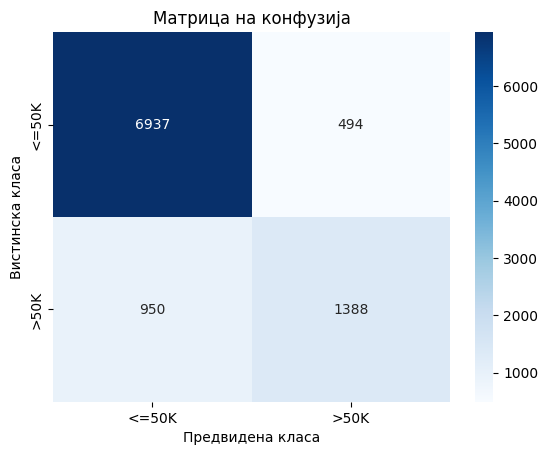

In [24]:
# 1. Пресметка на точност (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Точност (Accuracy): {accuracy * 100:.2f}%")

# 2. Приказ на детален извештај (Classification Report)
target_names = ['<=50K', '>50K'] # Имињата на класите од LabelEncoder
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# 3. Приказ на матрица на конфузија (Confusion Matrix)
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)

# Визуелизација на матрицата на конфузија
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Предвидена класа')
plt.ylabel('Вистинска класа')
plt.title('Матрица на конфузија')
plt.show()